<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

Alumno: Alexis Barniquez (a2203)

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Datos
Utilizaremos como corpus de texto el libro digital "La vuelta al mundo en 80 días"

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
import urllib.request

# URL directa al archivo .txt en español de "La vuelta al mundo en 80 días"
# El ID 21535 corresponde a este libro en Proyecto Gutenberg
url = "https://www.gutenberg.org/cache/epub/21535/pg21535.txt"

try:
    with urllib.request.urlopen(url) as response:
        # Leemos y decodificamos (usualmente utf-8)
        article_text = response.read().decode('utf-8')

    # Limpieza básica: quitar saltos de línea y pasar a minúsculas
    article_text = article_text.replace('\r', '').replace('\n', ' ')
    article_text = article_text.lower()

    print(f"Texto cargado exitosamente. Longitud: {len(article_text)} caracteres.")
    print("Primeros 200 caracteres:", article_text[:200])

except Exception as e:
    print(f"Error al cargar el texto: {e}")

Texto cargado exitosamente. Longitud: 267334 caracteres.
Primeros 200 caracteres: ﻿the project gutenberg ebook of die schwestern: drei novellen      this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no res


## Limpiamos el texto de caracteres especiales

In [4]:
import re
import unicodedata

def clean_text_for_nlp(text):
    # 1. Normalización Unicode (para manejar tildes y caracteres especiales uniformemente)
    text = unicodedata.normalize('NFKC', text)

    # 2. Eliminar números romanos (comunes en capítulos: I, II, IV, etc.)
    # Buscamos patrones de letras mayúsculas aisladas que parecen romanos
    text = re.sub(r'\b[ivxlcdm]+\b', '', text)

    # 3. Definir "White List" de caracteres permitidos
    # Mantenemos: letras (a-z), espacios y puntuación básica
    allowed_chars = r'[^a-zñáéíóúü\s\.,;:\?!\(\)\"\-]'
    text = re.sub(allowed_chars, '', text)

    # 4. Limpieza de espacios en blanco múltiples
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

article_text = clean_text_for_nlp(article_text)

# Verificación del nuevo vocabulario
chars_vocab = sorted(list(set(article_text)))
print(f"Nuevo tamaño del vocabulario: {len(chars_vocab)}")
print(f"Caracteres resultantes: {chars_vocab}")

Nuevo tamaño del vocabulario: 39
Caracteres resultantes: [' ', '!', '"', '(', ')', ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'é', 'ü']


In [5]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'the project gutenberg ebook of die schwestern: drei novellen this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever. you may copy it, give it away or re-use it under the terms of the project gutenberg license included with this ebook or online at www.gutenberg.org. if you are not located in the united states, you will have to check the laws of the country where you are located before using this ebook. title: die schwestern: drei novellen author: jakob wassermann release date: may , ebook language: german other information and formats: www.gutenberg.orgebooks credits: produced by markus brenner and the online distributed proofreading team at http:www.pgdp.net start of the project gutenberg ebook die schwestern: drei novellen produced by markus brenner and the online distributed proofreading team at http:www.pgdp.net die schwestern drei novellen von jakob wassermann dritte auflage s. fisch

In [6]:
# Recortamos el corpus a los primeros 50,000 caracteres
# Esto es más que suficiente para que la red aprenda palabras básicas y la PPL baje
article_text = article_text[:50000]

print(f"Corpus reducido a {len(article_text)} caracteres para agilizar el entrenamiento.")

Corpus reducido a 50000 caracteres para agilizar el entrenamiento.


### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [7]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [8]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [9]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [10]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

36

In [11]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [12]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [13]:
tokenized_text[:1000]

[18,
 12,
 5,
 29,
 9,
 22,
 24,
 13,
 5,
 4,
 18,
 29,
 0,
 1,
 18,
 5,
 31,
 16,
 5,
 22,
 0,
 29,
 5,
 16,
 24,
 24,
 19,
 29,
 24,
 28,
 29,
 3,
 30,
 5,
 29,
 25,
 4,
 12,
 26,
 5,
 25,
 18,
 5,
 22,
 31,
 32,
 29,
 3,
 22,
 5,
 30,
 29,
 31,
 24,
 14,
 5,
 21,
 21,
 5,
 31,
 29,
 18,
 12,
 30,
 25,
 29,
 5,
 16,
 24,
 24,
 19,
 29,
 30,
 25,
 29,
 28,
 24,
 22,
 29,
 18,
 12,
 5,
 29,
 1,
 25,
 5,
 29,
 24,
 28,
 29,
 20,
 31,
 6,
 24,
 31,
 5,
 29,
 20,
 31,
 6,
 26,
 12,
 5,
 22,
 5,
 29,
 30,
 31,
 29,
 18,
 12,
 5,
 29,
 1,
 31,
 30,
 18,
 5,
 3,
 29,
 25,
 18,
 20,
 18,
 5,
 25,
 29,
 20,
 31,
 3,
 29,
 33,
 24,
 25,
 18,
 29,
 24,
 18,
 12,
 5,
 22,
 29,
 9,
 20,
 22,
 18,
 25,
 29,
 24,
 28,
 29,
 18,
 12,
 5,
 29,
 26,
 24,
 22,
 21,
 3,
 29,
 20,
 18,
 29,
 31,
 24,
 29,
 4,
 24,
 25,
 18,
 29,
 20,
 31,
 3,
 29,
 26,
 30,
 18,
 12,
 29,
 20,
 21,
 33,
 24,
 25,
 18,
 29,
 31,
 24,
 29,
 22,
 5,
 25,
 18,
 22,
 30,
 4,
 18,
 30,
 24,
 31,
 25,
 29,
 26,
 12,
 20,
 18,
 2

### Organizando y estructurando el dataset

In [14]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [15]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [16]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [17]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [18]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [19]:
X.shape

(44900, 100)

In [20]:
X[0,:10]

array([18, 12,  5, 29,  9, 22, 24, 13,  5,  4])

In [21]:
y[0,:10]

array([12,  5, 29,  9, 22, 24, 13,  5,  4, 18])

In [22]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [23]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [24]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 36)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        47,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 36)       │         7,236 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,636 (213.42 KB)

 Trainable params: 54,636 (213.42 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [29]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data
      self.history_list = history_ppl
      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_list.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        #history_ppl.append(current_score)
        #print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

### Entrenamiento

In [30]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.7486
 mean perplexity: 10.019098281860352 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 2.4981
Epoch 2/20
174/176 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.1645
 mean perplexity: 9.458304405212402 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2.1371
Epoch 3/20
172/176 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.0793
 mean perplexity: 9.040400505065918 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2.0620
Epoch 4/20
174/176 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.0150
 mean perplexity: 8.421232223510742 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.0020
Epoch 5/20
173/176 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.9619
 mean perplexity: 8.006176948547363 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9483
Epoch 6/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.9114
 mean perplexity: 7.6950354576

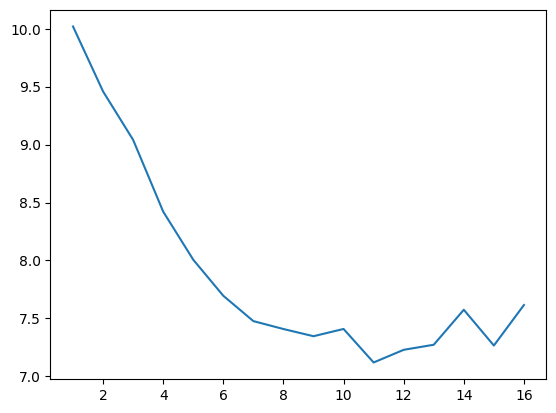

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [32]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [33]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [ ]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

### Generación de secuencias

In [34]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [35]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vezwicht geschleiden knig besien '

###  Beam search y muestreo aleatorio

In [36]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [37]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [38]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [39]:
salidas[0]

array([12, 20, 16, 30, 20, 29,  1, 31, 20, 29, 14,  5, 35, 26, 20, 22, 18,
        5, 31, 23, 29,  3, 30,  5, 29, 30, 31, 28, 20, 31, 18, 30, 31])

In [40]:
# veamos las salidas
decode(salidas[0])

'habia una vezwarten, die infantin'

# Solución

## Mejora de la arquitectura (LSTM)

In [41]:
from keras.layers import Input, LSTM, Embedding, Dense, Dropout
from keras.models import Sequential

# Definimos una arquitectura LSTM con capa de Embedding
#model_lstm = Sequential()

# El input_dim es el tamaño del vocabulario, el output_dim es el tamaño del vector denso
#model_lstm.add(Embedding(input_dim=vocab_size, output_dim=64))

# Primera capa LSTM con retorno de secuencias para apilar otra capa
#model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))

# Segunda capa LSTM
#model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))

# Capa densa de salida con activación softmax para predecir la probabilidad de cada caracter
#model_lstm.add(Dense(vocab_size, activation='softmax'))

#model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

#odel_lstm.summary()



model_lstm = Sequential()

# Le indicamos el tamaño de entrada de manera explícita
model_lstm.add(Input(shape=(max_context_size,)))
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=64))

# Agregamos las celdas recurrentes
model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))

# Salida
model_lstm.add(Dense(vocab_size, activation='softmax'))

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

# Ahora el summary mostrará correctamente los parámetros de tu arquitectura
model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100, 36)        │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,572 (3.30 MB)

 Trainable params: 865,572 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [42]:
history_ppl_lstm = []
hist = model_lstm.fit(X, y,
                      epochs=20,
                      callbacks=[PplCallback(tokenized_sentences_val,history_ppl_lstm)], batch_size=256)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 3.0062
 mean perplexity: 16.42078399658203 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 132s 693ms/step - loss: 2.9200
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - loss: 2.6862
 mean perplexity: 12.239962577819824 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 123s 698ms/step - loss: 2.5767
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 2.3224
 mean perplexity: 10.564702033996582 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 140s 690ms/step - loss: 2.2747
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 2.1439
 mean perplexity: 9.737502098083496 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 121s 688ms/step - loss: 2.1078
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - loss: 1.9978
 mean perplexity: 9.183650970458984 

Saved new model!
176/176 ━━━━━━━━━━━━━━━━━━━━ 121s 690ms/step - loss: 1.9686
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - loss: 1.8828
 mean per

## Generación de secuencias y evaluación de estrategias

### Greedy search

Esta estrategia selecciona siempre el caracter con la probabilidad más alta en cada paso. Es rápida, pero suele generar textos repetitivos o quedarse atrapada en bucles.

In [43]:
texto_semilla = "habia una vez"
# Usamos la función generate_seq
salida_greedy = generate_seq(model_lstm, texto_semilla, max_length=max_context_size, n_words=50)
print("Greedy Search:\n", salida_greedy)

Greedy Search:
 habia una vezleiden sich auf dem schwerzen und der knig zu schw


### Beam search determinístico

En lugar de mirar solo el siguiente caracter, mantiene las num_beams secuencias más probables en memoria. Genera un texto mucho más coherente que Greedy Search.

In [44]:
texto_semilla = "habia una vez"
# Ejecutamos con mode='det' para que sea determinístico
salidas_beam_det = beam_search(model_lstm, num_beams=5, num_words=50, input=texto_semilla, mode='det')

print("Beam Search Determinístico:")
# Imprimimos la mejor secuencia encontrada (la primera en la matriz de salidas)
print(decode(salidas_beam_det[0]))

Beam Search Determinístico:
habia una vezleichtete sich auf dem herzog und schleiderte sich


### Beam Search Estocástico y el Efecto de la Temperatura

Acá agregamos muestreo aleatorio ponderado por la probabilidad de la red. El parámetro de temperatura (temp) controla la "confianza" de la distribución de probabilidad (Softmax).

  - Temperatura Baja (<1.0): Acentúa las diferencias de probabilidad. Los caracteres probables se vuelven casi seguros, y los improbables se descartan. El texto es más correcto gramaticalmente, pero predecible.

  - Temperatura Alta (>1.0): Aplana la distribución. Da más oportunidad a caracteres menos probables. El modelo se vuelve más "creativo" o arriesgado, pero es más propenso a cometer errores ortográficos o generar galimatías.

In [45]:
texto_semilla = "habia una vez"

# Temperatura Baja (0.5): Más conservador
salidas_beam_sto_low = beam_search(model_lstm, num_beams=5, num_words=50, input=texto_semilla, temp=0.5, mode='sto')
print("Beam Search Estocástico (Temp = 0.5):")
print(decode(salidas_beam_sto_low[0]))
print("-" * 30)

# Temperatura Alta (1.5): Más arriesgado/creativo
salidas_beam_sto_high = beam_search(model_lstm, num_beams=5, num_words=50, input=texto_semilla, temp=1.5, mode='sto')
print("Beam Search Estocástico (Temp = 1.5):")
print(decode(salidas_beam_sto_high[0]))

Beam Search Estocástico (Temp = 0.5):
habia una vezlogen. sie hatte sich auf dem schmerzen und der in
------------------------------
Beam Search Estocástico (Temp = 1.5):
habia una vezrüchteten, die ihnen gewastern; sie ihn schrerstes


## Gráfica de comparación de convergencia RNN vs LSTM

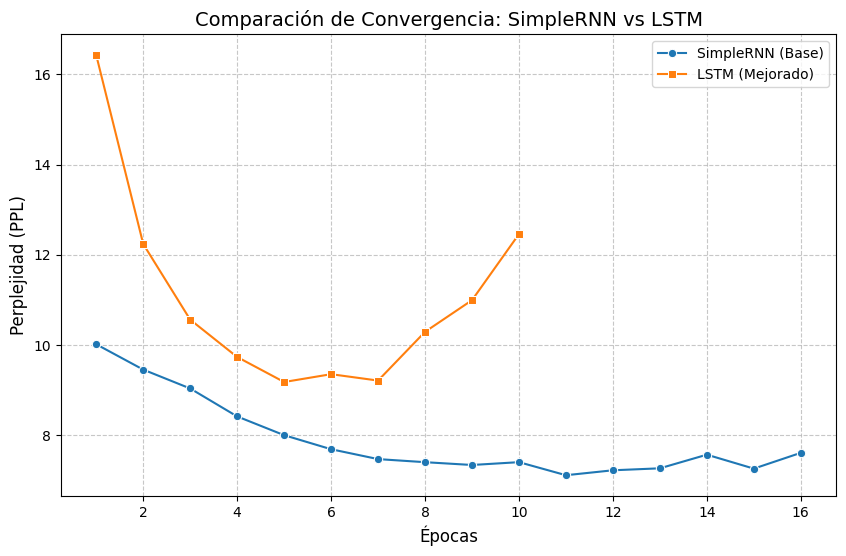

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Graficamos la curva del modelo original (SimpleRNN)
epochs_rnn = range(1, len(history_ppl) + 1)
sns.lineplot(x=epochs_rnn, y=history_ppl, marker="o", label='SimpleRNN (Base)')

# Graficamos la curva del nuevo modelo (LSTM)
epochs_lstm = range(1, len(history_ppl_lstm) + 1)
sns.lineplot(x=epochs_lstm, y=history_ppl_lstm, marker="s", label='LSTM (Mejorado)')

# Configuraciones
plt.title('Comparación de convergencia: SimpleRNN vs LSTM', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Perplejidad (PPL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()